## Aufgabe 1

Linearen Regression in Python, basierend auf den Daten in `birthweight_data.csv`.  
Das *Geburtsgewicht des Kindes* ist hier die Output-Variable.

Da lineare Regression viele unterschiedliche Fragen beantworten kann, gibt es verschiedene mögliche Analysen.

Beispielhafte Analysefragen:

##### Bibliotheken laden

In [1]:
import pandas as pd
import numpy as np
import sklearn
import io
from sklearn import linear_model
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
birthweight_data = pd.read_csv('../Data/Raw/birthweight_data.csv')
birthweight_data.head()

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109,12.0,12.0,1,1,1,0,6.8125
1,7.5,16.5,122.300003,133,6.0,12.0,2,1,0,0,8.3125
2,0.5,16.5,122.300003,129,NaN,12.0,2,0,0,0,8.0625
3,15.5,16.5,122.300003,126,12.0,12.0,2,1,0,0,7.8750
4,27.5,16.5,122.300003,134,14.0,12.0,2,1,1,0,8.3750


##### Daten prüfen

In [3]:
birthweight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   faminc    1388 non-null   float64
 1   cigtax    1388 non-null   float64
 2   cigprice  1388 non-null   float64
 3   bwght     1388 non-null   int64  
 4   fatheduc  1192 non-null   float64
 5   motheduc  1387 non-null   float64
 6   parity    1388 non-null   int64  
 7   male      1388 non-null   int64  
 8   white     1388 non-null   int64  
 9   cigs      1388 non-null   int64  
 10  bwghtlbs  1388 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 119.4 KB


### Aufgabe a)
Im einfachen linearen Regressionsmodell mit *nur `cigs`* als erklärende Variable:  
**Wie viele Zigaretten müsste die Mutter während der Schwangerschaft rauchen, damit ein Geburtsgewicht von 125 Unzen erreicht wird?**

In [4]:
# Daten laden
birthweight_data = pd.read_csv('../Data/Raw/birthweight_data.csv')

# Variablen definieren
x = birthweight_data[["faminc", "cigtax", "cigprice", "fatheduc", "motheduc", "parity", "male", "white", "cigs"]]
y = birthweight_data["bwght"]

birthweight_data.describe()

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
count,1388.000000,1388.000000,1388.000000,1388.000000,1192.000000,1387.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000
mean,29.026657,19.552954,130.559006,118.699568,13.186242,12.935833,1.632565,0.520893,0.784582,2.087176,7.418723
std,18.739285,7.795598,10.244485,20.353964,2.745985,2.376728,0.894027,0.499743,0.411260,5.972688,1.272123
min,0.500000,2.000000,103.800003,23.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.437500
25%,14.500000,15.000000,122.800003,107.000000,12.000000,12.000000,1.000000,0.000000,1.000000,0.000000,6.687500
50%,27.500000,20.000000,130.800003,120.000000,12.000000,12.000000,1.000000,1.000000,1.000000,0.000000,7.500000
75%,37.500000,26.000000,137.000000,132.000000,16.000000,14.000000,2.000000,1.000000,1.000000,0.000000,8.250000
max,65.000000,38.000000,152.500000,271.000000,18.000000,18.000000,6.000000,1.000000,1.000000,50.000000,16.937500


In [5]:
# modell erstellen mit statsmodels
model1 = sm.OLS(birthweight_data["bwght"], sm.add_constant(birthweight_data["cigs"])).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     32.24
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.66e-08
Time:                        17:38:19   Log-Likelihood:                -6135.5
No. Observations:                1388   AIC:                         1.227e+04
Df Residuals:                    1386   BIC:                         1.229e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        119.7719      0.572    209.267      0.000     118.649     120.895
cigs          -0.5138      0.090     -5.678      0.000      -0.691      -0.336
==============================================================================
Omnibus:                      118.187   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              635.742
Skew:                          -0.156   Prob(JB):                    8.92e-139
Kurtosis:                       6.301   Cond. No.                         6.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
# Lösung für die Aufgabe
# Daten
intercept = 119.7719
coef_cigs = -0.514

# gewünschtes Geburtsgewicht
target_bwght = 125

# Formel nach cig umstellen
cigs_needed = (target_bwght - intercept) / coef_cigs

cigs_needed

-10.171400778210112

##### Ergebnis
Das Modell ist:

$$bwght = 119.77 - 0.514 * cigs$$
$$125.42 = 119.77 - 0.514 * -11$$

Die Mutter müsste also -10 oder -11 Zigaretten geraucht haben um ein Gewicht von 125 Unzen zu erreichen. Dies ergibt natürlich keinen Sinn und zeigt damit auch direkt die Limitationen unseres noch sehr einfachen Modell auf.

### Aufgabe b)
Wenn das *Familieneinkommen* in das Modell aus (a) hinzugefügt wird, welches **Vorzeichen** hätte der Koeffizient wahrscheinlich?  
Sind **Zigarettenkonsum** und **Familieneinkommen** korreliert?  
Ist die Korrelation positiv oder negativ? Vergleicht das Ergebnis mit der Regression aus (a).

Ohne Python: Wenn das Familieneinkommen in das Modell aus (a) Modell hinzugefügt würde, welches Vorzeichen würde der Koeffizient für diese neue Variable wahrscheinlich haben?

**Antwort:**  Ein höheres Einkommen kann allgemein zu einer besseren vorgeburtlichen Betreuung oder einer besseren Ernährung der Mutter führen. Dies könnte dann die Gesundheit des Babys im Vergleich zu Frauen mit geringerem Einkommen (und daher weniger Zugang zu hochwertiger Schwangerschaftsvorsorge und besserer Ernährung) verbessern. Unter der Annahme, dass gesunde Babys ein höheres Geburtsgewicht haben als weniger gesunde, sollten wir davon ausgehen, dass ein höheres Familieneinkommen zu einem höheren Geburtsgewicht führen sollte (positive Korrelation). Dies würde bedeuten, dass der Koeffizient der unabhängigen Variable faminc positiv sein sollte, so dass ein Anstieg des Familieneinkommens auch zu einem Anstieg des Geburtsgewichts führen würde.

In [7]:
# mit Python
# Korrelation zwischen Einkommen und Zigaretten
corr = birthweight_data["faminc"].corr(birthweight_data["cigs"])

corr

np.float64(-0.1730449257358646)

### Interpretation der Korrelation zwischen `faminc` und `cigs`

Die berechnete Korrelation beträgt **-0.173**.  
Dies bedeutet:

- Es besteht ein **schwacher negativer Zusammenhang** zwischen dem Familieneinkommen und dem Zigarettenkonsum der Mutter.
- Ein höheres Einkommen geht tendenziell mit **weniger gerauchten Zigaretten** einher.
- Da der Wert nicht sehr stark ist (nicht z. B. -0.7 oder -0.8), handelt es sich eher um eine **leichte Tendenz**, keinen starken linearen Zusammenhang.

**Interpretation:**  
Mütter mit höherem Einkommen rauchen im Durchschnitt etwas weniger, aber das Einkommen erklärt nur einen kleinen Teil der Variation im Rauchverhalten.

Das Vorzeichen entspricht meiner Erwartung, da sozioökonomischer Status häufig mit gesundheitsbewussterem Verhalten zusammenhängt.

In [8]:
X_b = birthweight_data[["cigs", "faminc"]]
X_b = sm.add_constant(X_b)
y_b = birthweight_data["bwght"]

model2 = sm.OLS(y_b, X_b).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     21.27
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           7.94e-10
Time:                        17:38:27   Log-Likelihood:                -6130.4
No. Observations:                1388   AIC:                         1.227e+04
Df Residuals:                    1385   BIC:                         1.228e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.9741      1.049    111.512      0.000     114.916     119.032
cigs          -0.4634      0.092     -5.060      0.000      -0.643      -0.284
faminc         0.0928      0.029      3.178      0.002       0.036       0.150
==============================================================================
Omnibus:                      116.751   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              619.781
Skew:                          -0.154   Prob(JB):                    2.61e-135
Kurtosis:                       6.259   Cond. No.                         67.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Ergebnisse aus der Regression:**

- Der Koeffizient für **cigs** bleibt **negativ** und **signifikant**  
  → Mehr Zigaretten → niedrigeres Geburtsgewicht.

- Der Koeffizient für **faminc** ist **positiv** und **signifikant**  
  → Höheres Einkommen → etwas höheres Geburtsgewicht.

- Das R² erhöht sich gegenüber Modell (a) leicht auf ca. 0.03  
  → Das Modell erklärt nun etwas mehr Varianz.

### Aufgabe c)
Im Modell mit **allen erklärenden Variablen**:  
Welche Einflussfaktoren haben **statistische** und **praktische Signifikanz**?  
Welche Faktoren haben einen positiven bzw. negativen Einfluss?  

In [9]:
# Ersetzen der fehlenden Daten durch Mittelwert
birthweight_filled_copy = birthweight_data.copy()
birthweight_filled_copy["fatheduc"] = birthweight_data["fatheduc"].fillna(birthweight_data["fatheduc"].mean())
birthweight_filled_copy["motheduc"] = birthweight_data["motheduc"].fillna(birthweight_data["motheduc"].mean())

# Modell neu erstellen
model3 = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs"], axis=1))).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     8.800
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           5.80e-13
Time:                        17:38:30   Log-Likelihood:                -6112.6
No. Observations:                1388   AIC:                         1.225e+04
Df Residuals:                    1378   BIC:                         1.230e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.1316     12.535      8.308      0.000      79.543     128.721
faminc         0.0553      0.035      1.600      0.110      -0.013       0.123
cigtax         0.0694      0.144      0.481      0.631      -0.214       0.353
cigprice       0.0123      0.110      0.112      0.911      -0.203       0.227
fatheduc       0.2499      0.268      0.932      0.351      -0.276       0.776
motheduc      -0.0852      0.299     -0.285      0.776      -0.672       0.501
parity         1.7731      0.603      2.938      0.003       0.589       2.957
male           3.1180      1.070      2.914      0.004       1.019       5.217
white          5.4940      1.378      3.987      0.000       2.791       8.197
cigs          -0.4891      0.092     -5.318      0.000      -0.669      -0.309
==============================================================================
Omnibus:                      122.919   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.514
Skew:                          -0.139   Prob(JB):                    8.53e-155
Kurtosis:                       6.492   Cond. No.                     3.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Note: cigprice führt zu numerischen Unstimmigkeiten oder Multkollinearität, kann hier also auch ausgelassen werden.

### **Interpretation**

Diese Variablen haben einen nachweisbaren Einfluss auf das Geburtsgewicht:

- **cigs** (Zigaretten pro Tag) – *negativer Effekt*  
  → Jede zusätzliche Zigarette senkt das Geburtsgewicht um ca. **0.49 Einheiten**.  
  → **Wichtigster praktischer Einflussfaktor**, hoch signifikant.

- **parity** (Anzahl vorheriger Geburten) – *positiver Effekt*  
  → Mehr frühere Geburten führen zu höherem Geburtsgewicht.

- **male** (1 = Junge) – *positiver Effekt*  
  → Jungen sind im Durchschnitt schwerer als Mädchen.

- **white** (ethnische Zugehörigkeit) – *positiver Effekt*  
  → Weiße Babys haben im Durchschnitt ein höheres Geburtsgewicht.

Diese Variablen zeigen **keinen statistisch nachweisbaren Effekt**:

- **faminc** (Familieneinkommen)  
- **cigtax** (Zigarettensteuer)  
- **cigprice** (Zigarettenpreis)  
- **fatheduc** (Bildungsjahre Vater)  
- **motheduc** (Bildungsjahre Mutter)

#### **Praktische Bedeutung der Ergebnisse**

- Der stärkste praktische Einfluss ist der **Raucheffekt (cigs)**, der das Geburtsgewicht klar und unmittelbar senkt.  
- Andere signifikante Effekte (**parity**, **male**, **white**) verändern das Geburtsgewicht weniger stark, sind aber dennoch systematisch nachweisbar.  
- Das insgesamt niedrige **R²** zeigt, dass viele weitere medizinische und soziale Faktoren fehlen und das Modell nur einen kleinen Teil der realen Variation erklärt.

### Aufgabe d)

Welche einfache Lineare Regression (nur eine erklärende Variable), kann das Geburtsgewicht am besten erklären? Visualisiert diese Beziehung. Was ist die Interpretation des Koeffizienten und des Y-Achsenabschnittes hier?

In [10]:
# Herausfinden, welche Variable den höchsten R² Wert hat
result = {}
for var in birthweight_filled_copy.drop(["bwght", "bwghtlbs"], axis=1).columns:
    model = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy[var])).fit()
    result[var] = np.round(model.rsquared, 5)
result

print("Highest R^2 Value:", max(result, key=result.get))

Highest R^2 Value: cigs


Die Variable **`cigs`** (Zigaretten pro Tag) liefert das **höchste R² unter allen einfachen linearen Modellen** und erklärt damit das Geburtsgewicht am besten.

→ Rauchen der Mutter hat den stärksten linearen Zusammenhang mit dem Geburtsgewicht.
- **Koeffizient (`cigs`)**:  
  Gibt an, wie stark sich das Geburtsgewicht verändert, wenn die Mutter **eine zusätzliche Zigarette pro Tag** raucht.  
  → Negativer Wert bedeutet: Mehr Zigaretten = geringeres Geburtsgewicht.

- **Intercept (Achsenabschnitt)**:  
  Der geschätzte Wert des Geburtsgewichts, wenn die Mutter **null Zigaretten** raucht.  
  → Intercept zeigt also das erwartete Grundniveau des Geburtsgewichts ohne Rauchen.

Zur Darstellung der Beziehung zwischen *Geburtsgewicht* und *`cigs`* eignet sich eine **Scatterplot-Grafik** mit **Regressionsgerade**:

- Punkte = tatsächliche Daten  
- Linie = geschätzte lineare Beziehung  

Dies zeigt, wie stark und in welche Richtung der Zusammenhang verläuft.

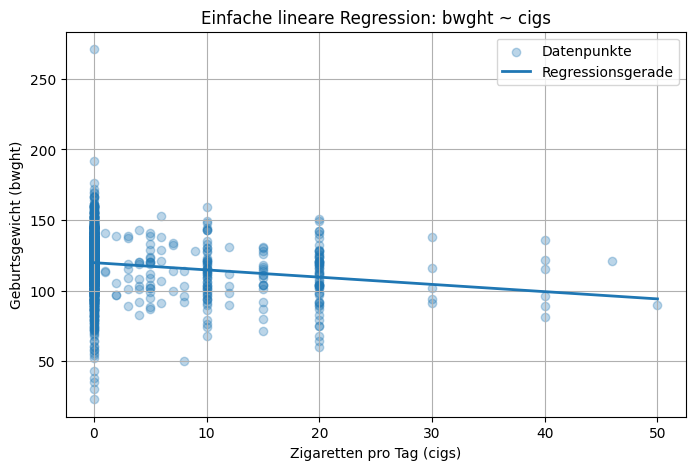

In [11]:
# Scatterplot + Regressionsgerade

plt.figure(figsize=(8, 5))

# Punkte (Daten)
plt.scatter(birthweight_filled_copy["cigs"], birthweight_filled_copy["bwght"], alpha=0.3, label="Datenpunkte")
# Regressionsgerade berechnen
cigs_range = np.linspace(birthweight_filled_copy["cigs"].min(), birthweight_filled_copy["cigs"].max(), 100)
bwght_pred = model.params["const"] + model.params["cigs"] * cigs_range

# Regressionsgerade plotten
plt.plot(cigs_range, bwght_pred, linewidth=2, label="Regressionsgerade")

# Achsenbeschriftungen und Titel
plt.xlabel("Zigaretten pro Tag (cigs)")
plt.ylabel("Geburtsgewicht (bwght)")
plt.title("Einfache lineare Regression: bwght ~ cigs")
plt.legend()
plt.grid(True)

plt.show()

### Aufgabe e)

Welchen Einfluss hat das Einkommen der Familie auf das Gewicht des Kindes bei Geburt? Ist dieser Einfluss von statistisch signifikant?

In [12]:
model4 = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1))).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     9.906
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.77e-13
Time:                        17:38:39   Log-Likelihood:                -6112.6
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1379   BIC:                         1.229e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.4645      3.878     27.196      0.000      97.857     113.072
faminc         0.0560      0.034      1.643      0.101      -0.011       0.123
cigtax         0.0836      0.069      1.207      0.228      -0.052       0.220
fatheduc       0.2497      0.268      0.932      0.352      -0.276       0.776
motheduc      -0.0864      0.299     -0.289      0.772      -0.672       0.500
parity         1.7708      0.603      2.937      0.003       0.588       2.953
male           3.1195      1.069      2.917      0.004       1.022       5.217
white          5.4866      1.376      3.988      0.000       2.788       8.185
cigs          -0.4891      0.092     -5.321      0.000      -0.669      -0.309
==============================================================================
Omnibus:                      122.977   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              710.047
Skew:                          -0.139   Prob(JB):                    6.53e-155
Kurtosis:                       6.493   Cond. No.                         312.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Positiver Einfluss, aber nicht statistisch signifikant.

### Aufgabe f)

Welche funktionale Form des Familieneinkommens ist am besten für die Lineare Regression geeignet?

In [13]:
print("Normal: ", np.round(sm.OLS(birthweight_data["bwght"],
                                  sm.add_constant(birthweight_data["faminc"])).fit().rsquared, 4))

print("Squared: ", np.round(sm.OLS(birthweight_data["bwght"],
                                   sm.add_constant(birthweight_data["faminc"]**2)).fit().rsquared, 4))

print("Cubed: ", np.round(sm.OLS(birthweight_data["bwght"],
                                 sm.add_constant(birthweight_data["faminc"]**3)).fit().rsquared, 4))

print("Log: ", np.round(sm.OLS(birthweight_data["bwght"],
                                 sm.add_constant(np.log(birthweight_data["faminc"]))).fit().rsquared, 4))

print("Square Root: ", np.round(sm.OLS(birthweight_data["bwght"],
                                       sm.add_constant(np.sqrt(birthweight_data["faminc"]))).fit().rsquared, 4))

print("Cube Root: ", np.round(sm.OLS(birthweight_data["bwght"],
                                       sm.add_constant(np.cbrt(birthweight_data["faminc"]))).fit().rsquared, 4))

Normal:  0.0119
Squared:  0.0081
Cubed:  0.0056
Log:  0.0112
Square Root:  0.0131
Cube Root:  0.0129


Tatsächlich hat die Quadratwurzel den höchsten $R^2$ Wert.

### Aufgabe g)
Welche Interaktionen der quantitativen Variable male sind statisch signifikant und sollten in das Modell miteinbezogen werden? Wie sind diese Interaktionen zu interpretieren?

In [14]:
result = {}
for var in birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice", "male"], axis=1).columns:
    birthweight_filled_copy["interaction"] = birthweight_filled_copy[var] * birthweight_filled_copy["male"]
    model5 = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1))).fit()
    result[var] = pd.read_html(io.StringIO(model5.summary().as_html()))[1].iloc[10][4]
result

{'faminc': '0.501',
 'cigtax': '0.018',
 'fatheduc': '0.571',
 'motheduc': '0.077',
 'parity': '0.687',
 'white': '0.748',
 'cigs': '0.998'}

In [15]:
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     8.799
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           5.83e-13
Time:                        17:38:49   Log-Likelihood:                -6112.6
No. Observations:                1388   AIC:                         1.225e+04
Df Residuals:                    1378   BIC:                         1.230e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         105.4648      3.883     27.162      0.000      97.848     113.082
faminc          0.0560      0.034      1.643      0.101      -0.011       0.123
cigtax          0.0836      0.069      1.206      0.228      -0.052       0.220
fatheduc        0.2497      0.268      0.930      0.352      -0.277       0.776
motheduc       -0.0864      0.299     -0.289      0.773      -0.673       0.500
parity          1.7708      0.603      2.936      0.003       0.588       2.954
male            3.1187      1.134      2.750      0.006       0.894       5.344
white           5.4866      1.376      3.986      0.000       2.787       8.186
cigs           -0.4893      0.138     -3.548      0.000      -0.760      -0.219
interaction     0.0004      0.181      0.002      0.998      -0.354       0.355
==============================================================================
Omnibus:                      122.977   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              710.042
Skew:                          -0.139   Prob(JB):                    6.55e-155
Kurtosis:                       6.493   Cond. No.                         312.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Interpretation der Interaktion (`male × cigtax`)**

Wir möchten evtl. die Interaktion zwischen male und cigtax zum Modell hinzufügen

Obwohl die Interaktion statistisch signifikant erscheint, ergibt sie **inhaltlich keinen plausiblen Zusammenhang**, da das Geschlecht des Kindes realistisch **keinen Einfluss darauf hat**, wie Zigarettensteuern das Verhalten der Mutter beeinflussen.  

Die gefundene Signifikanz ist daher **wahrscheinlich zufälliger Natur** oder ein **Artefakt des Datensatzes**, und sollte nicht als praktisch bedeutsam interpretiert werden.

In [25]:
birthweight_filled_copy["male_cigtax"] = birthweight_filled_copy["cigtax"] * birthweight_filled_copy["male"]
model6 = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1))).fit()
model6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     8.512
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.40e-13
Time:                        17:54:52   Log-Likelihood:                -6109.8
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1377   BIC:                         1.230e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    102.6444      4.052     25.329      0.000      94.695     110.594
faminc                     0.0609      0.035      1.734      0.083      -0.008       0.130
cigtax                     0.2414      0.096      2.513      0.012       0.053       0.430
fatheduc                   0.2499      0.269      0.931      0.352      -0.277       0.777
motheduc                  -0.1053      0.298     -0.353      0.724      -0.691       0.480
parity                     1.6932      0.603      2.808      0.005       0.510       2.876
male                       9.4590      2.887      3.277      0.001       3.796      15.122
white                      5.5246      1.374      4.020      0.000       2.829       8.220
cigs                      -0.4606      0.155     -2.980      0.003      -0.764      -0.157
interaction               -0.1624      0.069     -2.369      0.018      -0.297      -0.028
interaction_famic_cigs    -0.0017      0.007     -0.262      0.794      -0.015       0.011
male_cigtax               -0.1624      0.069     -2.369      0.018      -0.297      -0.028
==============================================================================
Omnibus:                      125.120   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              731.685
Skew:                          -0.147   Prob(JB):                    1.31e-159
Kurtosis:                       6.545   Cond. No.                     9.76e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.11e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

### Aufgabe h)
Welche **lineare Regression** erklärt das Geburtsgewicht insgesamt am besten?  
Wie hoch sind der **R²-Wert** und die **SSR** (Sum of Squared Residuals)?

In [29]:
print("R²:", model6.rsquared)
print("SSR:", model6.ssr)

R²: 0.05821669932900497
SSR: 541159.7220215711


1. Könnte der Effekt von cigs davon abhängen, wie gebildet die Mutter ist?

In [30]:
# Interaktionsvariable erstellen
birthweight_filled_copy["interaction1"] = (
    birthweight_filled_copy["cigs"] * birthweight_filled_copy["motheduc"]
)

X = birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1)
X = sm.add_constant(X)

model_interaction1 = sm.OLS(birthweight_filled_copy["bwght"], X).fit()
model_interaction1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     7.813
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           2.91e-13
Time:                        17:56:13   Log-Likelihood:                -6109.4
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1376   BIC:                         1.231e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    102.0726      4.101     24.890      0.000      94.028     110.117
faminc                     0.0572      0.035      1.618      0.106      -0.012       0.126
cigtax                     0.2422      0.096      2.521      0.012       0.054       0.431
fatheduc                   0.2402      0.269      0.894      0.372      -0.287       0.767
motheduc                  -0.0396      0.307     -0.129      0.897      -0.642       0.563
parity                     1.6803      0.603      2.786      0.005       0.497       2.864
male                       9.3714      2.888      3.245      0.001       3.705      15.037
white                      5.5139      1.374      4.012      0.000       2.818       8.210
cigs                       0.0393      0.570      0.069      0.945      -1.079       1.157
interaction_famic_cigs     0.0005      0.007      0.066      0.947      -0.013       0.014
male_cigtax               -0.3223      0.137     -2.350      0.019      -0.591      -0.053
interaction1              -0.0476      0.052     -0.911      0.362      -0.150       0.055
==============================================================================
Omnibus:                      125.143   Durbin-Watson:                   1.925
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              730.338
Skew:                          -0.149   Prob(JB):                    2.56e-159
Kurtosis:                       6.541   Cond. No.                     1.28e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Diese Interaktion verbessert das Model nicht und wird deshalb nicht mit aufgenommen.

In [31]:
birthweight_filled_copy = birthweight_filled_copy.drop(columns=["interaction1"])

2.Könnte der Effekt von famic (Einkommen) davon abhängen, ob die Mutter raucht (cigs)?

In [32]:
birthweight_filled_copy["interaction_faminc_cigs"] = (birthweight_filled_copy["faminc"] * birthweight_filled_copy["cigs"])

X = birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1)
X = sm.add_constant(X)

model_interaction2 = sm.OLS(birthweight_filled_copy["bwght"], X).fit()
model_interaction2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     8.512
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.40e-13
Time:                        17:56:36   Log-Likelihood:                -6109.8
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1377   BIC:                         1.230e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     102.6444      4.052     25.329      0.000      94.695     110.594
faminc                      0.0609      0.035      1.734      0.083      -0.008       0.130
cigtax                      0.2414      0.096      2.513      0.012       0.053       0.430
fatheduc                    0.2499      0.269      0.931      0.352      -0.277       0.777
motheduc                   -0.1053      0.298     -0.353      0.724      -0.691       0.480
parity                      1.6932      0.603      2.808      0.005       0.510       2.876
male                        9.4590      2.887      3.277      0.001       3.796      15.122
white                       5.5246      1.374      4.020      0.000       2.829       8.220
cigs                       -0.4606      0.155     -2.980      0.003      -0.764      -0.157
interaction_famic_cigs     -0.0009      0.003     -0.262      0.794      -0.007       0.006
male_cigtax                -0.3248      0.137     -2.369      0.018      -0.594      -0.056
interaction_faminc_cigs    -0.0009      0.003     -0.262      0.794      -0.007       0.006
==============================================================================
Omnibus:                      125.120   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              731.685
Skew:                          -0.147   Prob(JB):                    1.31e-159
Kurtosis:                       6.545   Cond. No.                     4.89e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.46e-24. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

Auch diese Interaktion lohnt sich nicht mit aufzunehemn, weil p= größer als 0.05 ist

In [ ]:
birthweight_filled_copy.drop(columns=["interaction_faminc_cigs"], inplace=True)

3.Kann Rauchen bei Erstgebärenden stärker wirken?

In [35]:
birthweight_filled_copy["cigs_parity"] = (birthweight_filled_copy["cigs"] * birthweight_filled_copy["parity"])

X = birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1)
X = sm.add_constant(X)

model_interaction3 = sm.OLS(birthweight_filled_copy["bwght"], X).fit()
model_interaction3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     8.643
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           7.98e-14
Time:                        18:02:44   Log-Likelihood:                -6109.2
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1377   BIC:                         1.230e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         102.2162      4.068     25.128      0.000      94.236     110.196
faminc          0.0599      0.034      1.759      0.079      -0.007       0.127
cigtax          0.2389      0.096      2.488      0.013       0.051       0.427
fatheduc        0.2652      0.268      0.991      0.322      -0.260       0.790
motheduc       -0.1070      0.298     -0.359      0.720      -0.692       0.478
parity          1.9082      0.632      3.020      0.003       0.669       3.148
male            9.5786      2.887      3.318      0.001       3.915      15.242
white           5.4494      1.375      3.964      0.000       2.753       8.146
cigs           -0.3129      0.183     -1.712      0.087      -0.671       0.046
male_cigtax    -0.3301      0.137     -2.407      0.016      -0.599      -0.061
cigs_parity    -0.0934      0.082     -1.140      0.254      -0.254       0.067
==============================================================================
Omnibus:                      125.907   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              742.152
Skew:                          -0.148   Prob(JB):                    6.98e-162
Kurtosis:                       6.570   Cond. No.                         352.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Nein lohnt sich auch nicht die Interaktion mit aufzunehmen, weil es nicht signifikat ist.

In [36]:
birthweight_filled_copy.drop(columns=["cigs_parity"], inplace=True)

4.Gehen gebildete Mütter anderst mit der Geburt eines Kindes um? parityxmotheduc

In [37]:
birthweight_filled_copy["parity_motheduc"] = (birthweight_filled_copy["parity"] * birthweight_filled_copy["motheduc"])

X = birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1)
X = sm.add_constant(X)

model_interaction4 = sm.OLS(birthweight_filled_copy["bwght"], X).fit()
model_interaction4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     8.603
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           9.44e-14
Time:                        18:10:33   Log-Likelihood:                -6109.4
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1377   BIC:                         1.230e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             107.7040      6.634     16.235      0.000      94.690     120.718
faminc              0.0601      0.034      1.765      0.078      -0.007       0.127
cigtax              0.2418      0.096      2.518      0.012       0.053       0.430
fatheduc            0.2426      0.268      0.905      0.366      -0.283       0.768
motheduc           -0.4949      0.502     -0.985      0.325      -1.480       0.490
parity             -1.1597      3.020     -0.384      0.701      -7.085       4.765
male                9.4868      2.886      3.287      0.001       3.826      15.148
white               5.4431      1.376      3.956      0.000       2.744       8.142
cigs               -0.4923      0.092     -5.363      0.000      -0.672      -0.312
male_cigtax        -0.3248      0.137     -2.370      0.018      -0.594      -0.056
parity_motheduc     0.2297      0.238      0.964      0.335      -0.238       0.697
==============================================================================
Omnibus:                      126.235   Durbin-Watson:                   1.921
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              744.377
Skew:                          -0.150   Prob(JB):                    2.29e-162
Kurtosis:                       6.575   Cond. No.                         650.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Auch diese Interaktion ist nicht signifikat.

In [38]:
birthweight_filled_copy.drop(columns=["parity_motheduc"], inplace=True)

5.Hat es einen Einfluss auf das modell wenn es sich um eine weiße oder schwarze Frau handelt?

In [39]:
birthweight_filled_copy["white_faminc"] = (birthweight_filled_copy["white"] * birthweight_filled_copy["faminc"])

X = birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1)
X = sm.add_constant(X)

model_interaction5 = sm.OLS(birthweight_filled_copy["bwght"], X).fit()
model_interaction5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     8.552
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.18e-13
Time:                        18:14:14   Log-Likelihood:                -6109.6
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1377   BIC:                         1.230e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          103.5998      4.300     24.091      0.000      95.164     112.036
faminc           0.0132      0.076      0.173      0.863      -0.137       0.163
cigtax           0.2402      0.096      2.501      0.012       0.052       0.429
fatheduc         0.2440      0.268      0.910      0.363      -0.282       0.770
motheduc        -0.1012      0.298     -0.339      0.735      -0.687       0.484
parity           1.6750      0.603      2.776      0.006       0.491       2.859
male             9.4838      2.886      3.286      0.001       3.822      15.146
white            4.4103      2.161      2.041      0.041       0.172       8.649
cigs            -0.4925      0.092     -5.365      0.000      -0.673      -0.312
male_cigtax     -0.3252      0.137     -2.372      0.018      -0.594      -0.056
white_faminc     0.0544      0.082      0.665      0.506      -0.106       0.215
==============================================================================
Omnibus:                      124.886   Durbin-Watson:                   1.921
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              729.609
Skew:                          -0.146   Prob(JB):                    3.69e-159
Kurtosis:                       6.540   Cond. No.                         455.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Aufgabe i) 
Welche **zusätzlichen Daten** könnten in das Modell aufgenommen werden, um es zu verbessern?

Das aktuelle Modell erklärt nur einen sehr kleinen Teil der Variation des Geburtsgewichts.  
Das liegt daran, dass viele wichtige medizinische, biologische und soziale Einflussfaktoren im Datensatz fehlen.

Folgende zusätzliche Variablen könnten das Modell deutlich verbessern:

##### **Medizinische Faktoren**
- Gesundheitszustand der Mutter (z. B. Diabetes, Bluthochdruck, BMI)
- Ernährungsstatus während der Schwangerschaft
- Alkohol- und Drogenkonsum
- Regelmäßigkeit der Schwangerschaftsvorsorge
- Schwangerschaftskomplikationen (z. B. Frühwehen, Infektionen)

##### **Lebensstil und Umweltfaktoren**
- Stresslevel der Mutter (Arbeitsbelastung, psychische Belastungen)
- Luftverschmutzung / Umweltgifte
- Schlafqualität und körperliche Aktivität

##### **Sozioökonomische Faktoren**
- Bildungsniveau der Eltern (genauer und getrennt erfasst)
- Familiäre Unterstützung
- Wohnverhältnisse (Überbelegung, Lärm, Wohnqualität)
- Zugang zum Gesundheitssystem

##### **Genetische Faktoren**
- Durchschnittliches Geburtsgewicht in der Familie
- Vererbte gesundheitliche Risiken

##### **Begründung**
Viele dieser Faktoren haben in der medizinischen Forschung große Bedeutung.  
Durch ihre Aufnahme in das Modell könnte die Erklärungskraft (R²) erheblich steigen und die Regressionskoeffizienten würden realistischere Zusammenhänge widerspiegeln.

### Aufgabe j)
Welche weiteren interessanten Erkenntnisse könnt ihr mit linearer Regression aus den Daten gewinnen?  
Was sind die **Limitationen** des Ansatzes?

### **Erkenntnisse aus dem Modell**
Auch wenn das Modell nur einen kleinen Teil der Variation des Geburtsgewichts erklärt (R² ≈ 0.058), lassen sich einige interessante Muster erkennen:

1. **Rauchen (cigs) hat den stärksten negativen Effekt.**  
   Jede zusätzliche Zigarette pro Tag senkt das Geburtsgewicht messbar.

2. **Frühere Geburten (parity) erhöhen das Geburtsgewicht.**  
   Kinder von Müttern, die bereits geboren haben, wiegen im Durchschnitt mehr.

3. **Jungen (male) und weiße Kinder (white) haben statistisch höhere Geburtsgewichte.**

4. **Die Interaktion `male × cigtax` ist signifikant.**  
   Der Effekt der Zigarettensteuer unterscheidet sich zwischen Jungen und Mädchen –  
   ein Hinweis auf unterschiedliche Verhaltens- oder Gruppeneffekte.

5. **Viele Variablen wie Einkommen oder Bildung zeigen keine signifikanten Effekte.**  
   Dies deutet darauf hin, dass andere wichtige Faktoren im Datensatz fehlen.

---

### **Limitationen der linearen Regression in diesem Kontext**

1. **Sehr geringer Erklärungsgehalt (niedriges R²).**  
   Das Modell kann nur etwa 5–6 % der Variation im Geburtsgewicht erklären.

2. **Wichtige medizinische und soziale Variablen fehlen.**  
   Ohne Informationen zu Gesundheit, Ernährung, Alkohol, Stress usw. bleibt das Modell unvollständig.

3. **Lineare Regression nimmt lineare Zusammenhänge an.**  
   In der Realität wirken viele Faktoren *nicht-linear* (z. B. Rauchen wirkt ab einer bestimmten Schwelle stärker).

4. **Keine kausalen Aussagen möglich.**  
   Regression zeigt Zusammenhänge – aber keine Ursache-Wirkung-Beziehungen.

5. **Störfaktoren (Confounder) werden möglicherweise nicht kontrolliert.**  
   → führt zu verzerrten Schätzungen.

6. **Interaktionen und nichtlineare Effekte werden kaum abgedeckt.**  
   Das Modell ist zu einfach, um komplexe biologische Prozesse abzubilden.

7. **Residualdiagnostik deutet auf mögliche Modellverletzungen hin.**  
   (z. B. Heteroskedastizität, Nicht-Normalverteilung, Ausreißer)

---

### **Fazit**
Die lineare Regression liefert erste Hinweise auf wichtige Einflussfaktoren des Geburtsgewichts.  
Für eine realistische Modellierung wären jedoch **umfangreichere Daten** und **flexiblere Modellansätze** nötig – etwa:

- nichtlineare Modelle  
- Regularisierungsmethoden  
- Entscheidungsbäume oder Random Forests  
- kausale Modelle  
- medizinische Risikoanalyse

## Aufgabe 2

Beschreibt jeweils zwei reale Anwendungen von Maschinellem Lernen, bei denen Klassifizierung / Regression / Clustering nützlich sein könnte. Beschreibt dabei sowohl die Output- und mögliche Input Variablen und ob der Fokus auf Vorhersage oder Inferenz liegt.

Erste Anwendung: Betrugserkennenung
    -ML-Typ: Klassifizierung
    -Output: Betrug / Kein Betrug
    -Inputs: Transaktionsmerkmale
    -Fokus: Vorhersage

Zweite Anwendung: AKtien-Vorhersage
    -ML-Typ: Regression
    -Output-Variable: z.B. price_tomorrow = Aktienkurs am nächsten Tag
    -Mögliche Input-Variablen:
        -Historische Preise der letzten Tage/Wochen
        -Handelsvolumen
        -Marktindex (z. B. DAX, S&P500)
        -Sektor-Index (Tech, Energie, …)
        -evtl. einfache technische Indikatoren (gleitende Durchschnitte o. Ä.)
    -Fokus: hier eher Vorhersage (Forecasting), nicht erklären „warum“ genau die Aktie steigt.

## Aufgabe 3

Was misst der $R^2$ Wert? Ist eine Regression nutzlos wenn dieser Wert gering ist?

**Antwort**: Der $R^2$ Wert liegt zwischen 0 und 1 und misst den Anteil der Varianz in der abhängigen Variable, der durch die unabhängigen Variablen im Modell erklärt wird. Wir berechnen ihn durch:

$$ R^2 = 1 - \frac{SSR}{SST}$$

Eine Regression ist nicht nutzlos wenn der Wert gering ist, diese Betrachtung ist immer in Hinblick auf die Modelldefinition (wie viele Inputvariablen), die Daten (wie viele Datensätze, wie viel Varianz in der Outputvariable), und das Ziel der Analyse (Vorhersage, Inferenz) zu treffen.

## Aufgabe 4
Angenommen das wahre Modell für Wert von Bildung ist:

$$wage= \beta_0+ \beta_1 exper+ \beta_2 exper^2$$

Was ist die Konsequenz wenn wir die Regression ohne den Quadratischen Teil modellieren?

**Antwort**: Wenn das wahre Modell einen quadratischen Zusammenhang zwischen Berufserfahrung (`exper`) und Lohn (`wage`) enthält, führt die Schätzung eines rein linearen Modells zu einer falschen Modellspezifikation.

Da `exper²` weggelassen wird, entsteht ein Omitted Variable Bias: Die Schätzung von β₁ (dem Effekt der linearen Erfahrung) wird verzerrt, weil sie versucht, die eigentlich gekrümmte Beziehung als Gerade darzustellen. Dadurch passen die Vorhersagen schlechter, und die Residuen zeigen systematische Muster, die auf fehlende Nichtlinearität hinweisen.

Kurz: Das Modell ist unvollständig, liefert verzerrte Schätzer und fängt die wahre Beziehung nicht korrekt ein.

## Aufgabe 5
Was sind Möglichkeiten die akademische Ausbildung einer Person als kategorische oder numerische Variable abzubilden? Warum könnte eine kategorische / ordinale Modellierung bevorzugt werden?

Akademische Ausbildung kann auf unterschiedliche Arten als Variable modelliert werden.  
Typische Stufen wären z. B. Hauptschulabschluss, Realschule, Abitur, Bachelor, Master, Promotion.

### Möglichkeit 1: Numerische Modellierung
Man könnte diesen Stufen Zahlen zuordnen (z. B. 1–6).  
Dies ist jedoch problematisch, weil die lineare Regression dann automatisch annimmt, dass die Abstände zwischen den Stufen gleich groß sind.  
Der Sprung von „Hauptschule → Realschule“ wäre dann im Modell genauso groß wie „Master → Promotion“, obwohl diese Unterschiede in der Realität nicht vergleichbar sind.

### Möglichkeit 2: Kategorische bzw. ordinale Modellierung
Statt feste Zahlen zu vergeben, kann man Ausbildung als **kategoriale Variable** (mit Dummy-Codierung) oder als **ordinale Variable** mit einer Reihenfolge darstellen.  
Dies hat den Vorteil, dass das Modell **nicht** davon ausgeht, dass alle Abstände gleich sind.  
Jede Ausbildungsstufe kann ihren **eigenen Effekt** haben, was realistischer ist, da die Bildungsstufen qualitativ und quantitativ sehr unterschiedliche Abstände besitzen.

### Fazit
Die ordinale bzw. kategoriale Modellierung wird bevorzugt, weil sie flexibler ist und realistischere Zusammenhänge abbildet. Numerische Kodierung kann dagegen zu falschen linearen Annahmen und verzerrten Schätzungen führen.

## Aufgabe 6

Für einen Datensatz mit fünf Input-Variablen, X1 = Notendurchschnitt, X2 = IQ, X3 = Level (1 für Universität und 0 für Gymnasium), X4 = Interaktion zwischen Notendurchschnitt und IQ und X5 = Interaktion zwischen Notendurchschnitt und Level. Die Output-Variable ist das Anfangsgehalt nach dem Abschluss. Das Ergebnis der Linearen Regression ist: $\beta_0=50, \beta_1=20,\beta_2=0,007, \beta_3=35, \beta_4=0,001 \text{ und } \beta_5= −10$

a) Was ist das Gehalt eines Universitätsabsolventen mit einem IQ von 110 und einem Notendurchschnitt von 4,0?

**Antwort:** Es hilft das Modell einmal in traditioneller Form zu schreiben:

$$wage = 50 + 20 * Note + 0.007 * IQ + 35 * Level + 0.001 * (Noten * IQ) -10 * (Note * Level)$$

$$wage = 50 + 20 * 4 + 0.007 * 110 + 35 * 1 + 0.001 * (4 * 110) -10 * (4 * 1) = 126.21$$

b) Richtig oder falsch: Da der Koeffizient für den Interaktionsterm von Notendurschnitt und IQ sehr klein ist, gibt es nur sehr wenige Hinweise auf einen Interaktionseffekt. 

**Antwort**: Die Größe des Koeffizienten allein ist kein ausreichender Hinweis darauf, ob ein Interaktionsterm wichtig ist. 
Die Bedeutung hängt sowohl von der Skala der beteiligten Variablen als auch vom Standardfehler ab. Da Note × IQ Werte im Bereich von etwa 70 bis 650 annehmen kann, führt selbst ein kleiner Koeffizient (0.001) zu einem messbaren Effekt auf den Lohn (ca. 0.07 bis 0.65).

Ohne den Standardfehler zu kennen, kann man keine Aussage über die statistische Signifikanz treffen. 
Daher ist die Behauptung, der Interaktionsterm sei „klein“ einfach nur aufgrund der Koeffizientengröße, falsch.

## Aufgabe 7
Angenommen es gibt eine Lineare Regression mit drei unabhängigen Variablen:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$$

Wie lässt sich durch Umschreiben und Reparametrisierung des Modell die Hypothese $H_0: \beta_1 - 3\beta_2 = 1$ einfach testen?

Gegeben sei das Modell:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3
$$

Wir möchten die Hypothese

$$
H_0: \beta_1 - 3\beta_2 = 1
$$

einfach testen. Dazu definieren wir neue Parameter:

$$
\alpha_1 = \beta_1 - 3\beta_2,
\qquad
\alpha_2 = \beta_2.
$$

Damit folgt:

$$
\beta_1 = \alpha_1 + 3\alpha_2.
$$

Wir setzen dies in das Modell ein:

$$
\beta_1 x_1 + \beta_2 x_2
= (\alpha_1 + 3\alpha_2)x_1 + \alpha_2 x_2
= \alpha_1 x_1 + \alpha_2 (3x_1 + x_2)
$$

Das umgeschriebene Modell lautet damit:

$$
y = \beta_0 + \alpha_1 x_1 + \alpha_2(3x_1 + x_2) + \beta_3 x_3.
$$

In dieser Darstellung lässt sich die ursprüngliche Hypothese sehr einfach testen:

$$
H_0: \alpha_1 = 1.
$$

Somit kann die Hypothese durch einen gewöhnlichen t-Test auf den Koeffizienten von \(x_1\) 
im reparametrisierten Modell geprüft werden.